# Pêndulo com interação elétrica

![Exercicio01](../00_images/99_notebooks/01_01.webp)

Podemos resolver este problema diretamente com as leis de Newton, ou no formalismo Lagrangeano, em coordenadas cartesianas ou polares. No caso, vamos escrever a lagrangeana em coordenadas polares e derivar as equações de movimento.

Para tanto, usaremos as variáveis cartesianas $x$ e $z$ com a seguinte relação com as grandezas angulares:

$$
x=L\sin\theta, \; z=L(1-\cos\theta)
$$

O termo de energia cinética contém apenas a velocidade angular: 
$$
T = \frac{1}{2}mL {\dot \theta}^2,
$$

A energia potencial tem a contribuição do peso e da força elétrica: 

$$
U_g = mgL(1-\cos\theta) \\
U_e = kqQ\left(\frac{1}{r_+}+\frac{1}{r_-}\right),\\
r_\pm =\sqrt{(L\sin\theta\mp D/2)^2+[L(1-\cos\theta)]^2}
$$

- Lagrangeana:  
  $$
  \mathcal{L}=T-U=T-(U_g+U_e)
  $$

As equações de movimento são obtidas com as equações de Euler-Lagrange

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot\theta} \right) + \frac{\partial \mathcal{L}}{\partial \theta} = 0
$$









In [13]:

import sympy as sp
from IPython import display

# Símbolos
m, q, Q, D, L, g, k, t = sp.symbols("m q Q D L g k t", positive=True, real=True)
theta = sp.symbols("theta", real=True)
thetadot = sp.symbols("thetadot", real=True)
theta_t = sp.Function("theta")(t)

# Coordenadas
x = L * sp.sin(theta)
z = L * (1 - sp.cos(theta))

# Distâncias
r_plus  = sp.sqrt((x - D / 2) ** 2 + z ** 2)
r_minus = sp.sqrt((x + D / 2) ** 2 + z ** 2)

# Energias
T = sp.Rational(1, 2) * m * (L ** 2) * (thetadot ** 2)
U_g = m * g * z
U_e = k * q * Q * (1 / r_plus + 1 / r_minus)
U = U_g + U_e

# Lagrangiana
Lag = T - U

# Segunda derivada para pequenas oscilações
K_eff = sp.diff(U, theta, 2).subs(theta, 0)
omega2 = sp.simplify(K_eff / (m*L**2))
I = m * L**2
Lag, sp.simplify(omega2)
Lag_str = r"$$\mathcal{L} = " + sp.latex(Lag) + r"$$"

eom = sp.diff(sp.diff(Lag, thetadot).subs(thetadot, sp.diff(theta_t, t)), t) - sp.diff(
    Lag, theta
).subs({theta: theta_t, thetadot: sp.diff(theta_t, t)})

eom_str = r"$$" + sp.latex(eom) + r" = 0$$"
eom_ln = eom.subs({theta_t: theta}).series(theta, 0, 2).removeO()
accel = eom_ln / I
w2 = (accel / theta).simplify()
eom_ln_str = r"$$ \ddot \theta + " + sp.latex(eom_ln) + r" = 0$$"
w2_str = r"$$ \omega^2 = " + sp.latex(w2) + r" $$"


In [14]:
display.Latex(Lag_str)

<IPython.core.display.Latex object>

In [15]:
display.Latex(eom_str)

<IPython.core.display.Latex object>

In [16]:
display.Latex(eom_ln_str)

<IPython.core.display.Latex object>

In [17]:
display.Latex(w2_str)

<IPython.core.display.Latex object>


## Condição de Estabilidade

- Para estabilidade:  
  $$
  \omega^2 = \frac{g}{L} + \frac{32kqQ}{mD^3} > 0
  $$

- Se $qQ>0$: termo elétrico estabiliza.  
- Se $qQ<0$: pode desestabilizar se $|qQ|>\tfrac{gmD^3}{32kL}$.


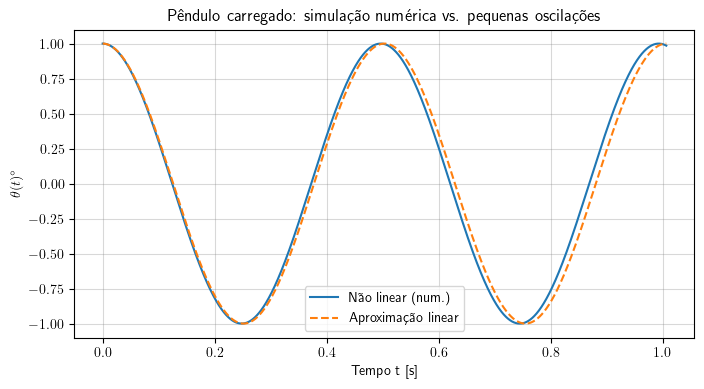

In [19]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    "m": 0.25,            # kg
    "q": 2.0e-7,          # C
    "Q": 5.0e-6,          # C
    "D": 0.20,            # m
    "L": 0.80,            # m
    "g": 9.81,            # m/s^2
    "k": 8.9875517923e9,  # N m^2 / C^2
}

theta0 = np.deg2rad(1.0)
thetadot0 = 0.0

omega2 = params["g"] / params["L"] + 32 * params["Q"] * params["k"] * params["q"] / (
    params["D"] ** 3 * params["m"]
)
omega = np.sqrt(omega2) if omega2 > 0 else np.nan

t0, tf = 0.0, 2 * 2 * np.pi / omega
t_eval = np.linspace(t0, tf, 2500)

def dU_dtheta_numeric(theta, p):
    L, g, m, q, Q, D, k = p["L"], p["g"], p["m"], p["q"], p["Q"], p["D"], p["k"]
    x = L*np.sin(theta)
    z = L*(1 - np.cos(theta))
    r_plus  = np.sqrt((x - D/2.0)**2 + z**2)
    r_minus = np.sqrt((x + D/2.0)**2 + z**2)
    dx_dtheta = L*np.cos(theta)
    dz_dtheta = L*np.sin(theta)
    dU = m*g*dz_dtheta
    dU += k*q*Q * ( -((x - D/2.0)*dx_dtheta + z*dz_dtheta)/r_plus**3
                    -((x + D/2.0)*dx_dtheta + z*dz_dtheta)/r_minus**3 )
    return dU

def eom(t, y, p):
    theta, thetadot = y
    L, m = p["L"], p["m"]
    thetaddot = - dU_dtheta_numeric(theta, p) / (m*L**2)
    return [thetadot, thetaddot]

sol = solve_ivp(eom, (t0, tf), [theta0, thetadot0], t_eval=t_eval, args=(params,), rtol=1e-9, atol=1e-9)


theta_lin = theta0*np.cos(omega*sol.t) if omega2 > 0 else np.nan*np.zeros_like(sol.t)
plt.rcParams["text.usetex"] = True

if np.isfinite(omega):
    plt.figure(figsize=(8,4))
    plt.plot(sol.t, np.degrees(sol.y[0]), label="Não linear (num.)")
    plt.plot(sol.t, np.degrees(theta_lin), linestyle="--", label="Aproximação linear")
    plt.xlabel("Tempo t [s]")
    plt.ylabel(r"$\theta(t)^\circ$")
    plt.title("Pêndulo carregado: simulação numérica vs. pequenas oscilações")
    plt.legend()
    plt.grid(True, alpha=0.3, color="gray")
    plt.show()
